In [1]:
import numpy as np
import cv2
from dataclasses import dataclass
from scipy.ndimage import gaussian_filter1d
from typing import Optional, Tuple
from dataclasses import dataclass
import matplotlib.pyplot as plt
from CV.utils import tensor_to_video as t2v

In [403]:



# ------------------ small utils ------------------


left_camera = np.load('/workspace/test_results/cam1_1754410796.npy')
right_camera = np.load('/workspace/test_results/cam2_1754410796.npy')





@dataclass
class BEVGrid:
    """Defines the bird's‑eye grid in world meters."""
    meters_per_pixel: float = 0.05
    forward_range_m: tuple[float, float] = (0.0, 30.0)   # (y_min, y_max) forward
    lateral_range_m: tuple[float, float] = (-5.0, 5.0)   # (x_min, x_max) left/right

    @property
    def size(self) -> tuple[int, int]:
        """(W_out, H_out) in pixels for cv2.warpPerspective"""
        x_min, x_max = self.lateral_range_m
        y_min, y_max = self.forward_range_m
        W_out = int(np.round((x_max - x_min) / self.meters_per_pixel))
        H_out = int(np.round((y_max - y_min) / self.meters_per_pixel))
        return (W_out, H_out)

    def scaling_matrix(self) -> np.ndarray:
        """
        S maps destination pixel coords (u,v,1)^T to ground meters (x,y,1)^T.
        y grows forward; we place y forward downward in the BEV image so rows increase with distance.
        """
        x_min, _x_max = self.lateral_range_m
        _y_min, y_max = self.forward_range_m
        mpp = self.meters_per_pixel
        S = np.array([[ mpp,  0.0, x_min],
                      [ 0.0, -mpp, y_max],
                      [ 0.0,  0.0, 1.0 ]], dtype=np.float64)
        return S

class BEVProjector:
    """
    Bird's‑eye view projector.

    Supports:
      1) Calibrated plane homography (ground z=0) using intrinsics + pose.
      2) Trapezoid→rectangle homography (no calibration).

    Conventions:
      World: X right, Y forward, Z up.
      Camera (OpenCV): x right, y down, z forward.
      roll/pitch/yaw are applied as world->camera, ZYX order (yaw, pitch, roll).
    """

    def __init__(self, K: np.ndarray | None = None):
        self.K = None if K is None else self._validate_K(K)
        self.roll = 0.0
        self.pitch = 0.0
        self.yaw = 0.0
        self.height_m = 1.0
        self._H_pg = None  # ground->image homography (if calibrated set)

    # ---------- Public API ----------

    def set_intrinsics(self, K: np.ndarray) -> "BEVProjector":
        self.K = self._validate_K(K)
        self._H_pg = None
        return self

    def set_pose(self, height_m: float, roll: float = 0.0, pitch: float = 0.0, yaw: float = 0.0) -> "BEVProjector":
        self.height_m = float(height_m)
        self.roll = float(roll)
        self.pitch = float(pitch)
        self.yaw = float(yaw)
        self._H_pg = None
        return self

    def warp_calibrated(self, mask01: np.ndarray, grid: BEVGrid) -> np.ndarray:
        """
        Warp a binary mask (1/0, bool or uint8) to BEV using calibration.
        Returns uint8 0/255 mask of shape (H_out, W_out).
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()  # 3x3
        self.H_pg = H_pg
        
        S = grid.scaling_matrix()
        self.S = S
        

        # We need M such that dst <- src: p_dst = S^{-1} * H_pg^{-1} * p_img
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        self.M = M

        
        src = self._to_uint8_255(mask01)
        W_out, H_out = grid.size
        
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        
        return bev

    def warp_trapezoid(self, mask01: np.ndarray, src_quad: np.ndarray, out_size: tuple[int, int]) -> np.ndarray:
        """
        Warp a perspective trapezoid to a rectangle (no calibration needed).
        src_quad: 4x2 float32 in order [TL, TR, BR, BL]
        out_size: (W_out, H_out)
        """
        src = self._to_uint8_255(mask01)
        W_out, H_out = out_size
        dst_quad = np.array([[0, 0],
                             [W_out - 1, 0],
                             [W_out - 1, H_out - 1],
                             [0, H_out - 1]], dtype=np.float32)
        M = cv2.getPerspectiveTransform(src_quad.astype(np.float32), dst_quad)
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        return bev

    def get_calibrated_homography(self, grid: BEVGrid) -> np.ndarray:
        """
        Returns the overall SRC->DST warp matrix M for calibrated BEV:
            p_dst = M * p_img
        so you can reuse it for many frames.
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()
        S = grid.scaling_matrix()
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        return M

    # ---------- Internals ----------

    @staticmethod
    def _validate_K(K: np.ndarray) -> np.ndarray:
        K = np.asarray(K, dtype=np.float64)
        if K.shape != (3, 3) or not np.isfinite(K).all():
            raise ValueError("K must be 3x3 finite matrix")
        return K

    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        """
        World:  X right, Y forward, Z up
        Camera: x right, y down,   z forward (OpenCV)
        Rotate in WORLD (yaw->pitch->roll), then align world->camera.
        """
        # Base alignment: Xw->xc, Yw->zc, Zw->-yc
        R_align = np.array([
            [1.0, 0.0,  0.0],  # Xw -> +xc
            [0.0, 0.0, -1.0],  # Zw -> -yc
            [0.0, 1.0,  0.0],  # Yw -> +zc
        ], dtype=np.float64)
    
        cz, sz = np.cos(yaw),   np.sin(yaw)
        cy, sy = np.cos(pitch), np.sin(pitch)
        cx, sx = np.cos(roll),  np.sin(roll)
    
        Rz = np.array([[ cz, -sz, 0],
                       [ sz,  cz, 0],
                       [  0,   0, 1]], dtype=np.float64)
        Ry = np.array([[ cy, 0, sy],
                       [  0, 1,  0],
                       [-sy, 0, cy]], dtype=np.float64)
        Rx = np.array([[1,  0,   0],
                       [0, cx, -sx],
                       [0, sx,  cx]], dtype=np.float64)
    
        R_world = Rx @ Ry @ Rz          # world -> rotated-world
        return R_align @ R_world        # world -> camera

    def _ground_to_image_homography(self) -> np.ndarray:
        """
        Builds H_pg such that p_img ~ H_pg * p_ground (z=0 plane).
        H_pg = K [r1 r2 t], where t = -R*C and C=(0,0,h)^T (camera center in world).
        """
        if self._H_pg is not None:
            return self._H_pg

        R_wc = self._rot_from_rpy(self.roll, self.pitch, self.yaw)  # world->camera
        t_wc = np.array([[0.0], [0.0], [self.height_m]], dtype=np.float64)  # camera at (0,0,h) in world

        r1 = R_wc[:, 0:1]
        r2 = R_wc[:, 1:2]
        t = R_wc @ (-t_wc)  # -R*C
        H_pg = self.K @ np.hstack([r1, r2, t])
        self._H_pg = H_pg
        return H_pg

    @staticmethod
    def _to_uint8_255(mask01: np.ndarray) -> np.ndarray:
        """Ensure input is uint8 in {0,255} for nearest-neighbor warps."""
        if mask01.dtype != np.uint8:
            src = (mask01.astype(np.uint8) * 255)
        else:
            src = mask01.copy()
            if src.max() == 1:
                src *= 255
        return src







def make_projector_and_grid(
    frame_shape: Tuple[int, int],          # (H, W) of your input npy frame
    *,
    fx: float = 1100.0,
    fy: Optional[float] = None,
    roll_deg: float = 0.0,
    pitch_deg_down: float = 6.0,
    yaw_deg: float = 0.0,
    height_m: float = 1.4,
    meters_per_pixel: float = 0.10,
    forward_range: Tuple[float, float] = (0.5, 40.0),
    lateral_range: Tuple[float, float] = (-8.0, 8.0),
) -> tuple:
    """Build and return (projector, grid) once, then reuse them for all frames."""
    H, W = frame_shape
    fy_loc = fx if fy is None else fy
    K = np.array([[fx,    0.0,  W / 2.0],
                  [0.0,  fy_loc, H / 2.0],
                  [0.0,   0.0,   1.0   ]], dtype=np.float64)

    roll  = np.deg2rad(roll_deg)
    pitch = -np.deg2rad(pitch_deg_down)   # down is negative in this convention
    yaw   = np.deg2rad(yaw_deg)

    projector = BEVProjector().set_intrinsics(K).set_pose(
        height_m=height_m, roll=roll, pitch=pitch, yaw=yaw
    )
    grid = BEVGrid(
        meters_per_pixel=meters_per_pixel,
        forward_range_m=forward_range,
        lateral_range_m=lateral_range
    )
    return projector, grid


def npy_frame_to_bev(
    seg_frame: np.ndarray,                 # (H, W) labels or binary
    projector: "BEVProjector",
    grid: "BEVGrid",
    *,
    road_label: tuple = (0, 1) 
) -> np.ndarray:
    """
    Use your BEVProjector/BEVGrid to warp a single npy frame to BEV.
    Returns uint8 BEV mask (H_out, W_out) with values {0,255}.
    """
    # Build 1/0 mask (road=1). If already binary uint8, just threshold.
    mask01 = np.isin(seg_frame, road_label)
    bev = projector.warp_calibrated(mask01=mask01, grid=grid)  # returns uint8 {0,255}
    return bev





def make_oriented_road_image(
    h=256, w=256, *,
    angle_deg=0.0,
    cx=None, cy=None,
    bg_val=30, road_val=120, edge_val=190, dash_val=235,
    road_width_bottom=0.9, road_width_top=0.15,
    edge_thickness=2.0,
    dash_period=28.0, dash_duty=0.55,
    dash_scroll_px=0.0,           # increase over time: e.g. t * dash_speed_px
):
    if cx is None: cx = (w - 1) * 0.5
    if cy is None: cy = (h - 1) * 0.0   # <-- FIX: center vertically

    y, x = np.mgrid[0:h, 0:w].astype(np.float32)
    xd = x - cx
    yd = y - cy

    theta = np.deg2rad(angle_deg)
    c, s = np.cos(theta), np.sin(theta)

    xp =  xd * c + yd * s
    yp = -xd * s + yd * c

    yprime = yp + cy

    t  = np.clip(yprime / max(h - 1.0, 1.0), 0.0, 1.0)
    tb = 1.0 - t

    half_w_top = (road_width_top * w) * 0.5
    half_w_bot = (road_width_bottom * w) * 0.5
    half_w     = half_w_top + (half_w_bot - half_w_top) * tb

    dist = np.abs(xp)

    img = np.full((h, w), float(bg_val), dtype=np.float32)

    edge_soft = 0.6 + (1.6 - 0.6) * tb
    road_mask = 1.0 - np.clip((dist - half_w) / np.maximum(edge_soft, 1e-6), 0.0, 1.0)
    img = img * (1.0 - road_mask) + road_val * road_mask

    thick = 0.5 + (edge_thickness - 0.5) * tb
    edge_dist = np.abs(dist - half_w)
    edge_mask = np.exp(-(edge_dist**2) / (2.0 * (np.maximum(thick, 1e-6) ** 2)))
    img = img * (1.0 - edge_mask) + edge_val * edge_mask

    # --- moving dashes (scroll 'toward' the bottom when dash_scroll_px grows) ---
    center_thick = 0.5 + (2.2 - 0.5) * tb
    period = 10.0 + (dash_period - 10.0) * tb
    dash_len = dash_duty * period

    # Use a minus so increasing scroll moves dashes "down" in screen space
    phase = ((yprime - dash_scroll_px) / np.maximum(period, 1e-6)) % 1.0
    is_dash = (phase <= (dash_len / np.maximum(period, 1e-6))).astype(np.float32)

    centerline_profile = np.exp(-(dist**2) / (2.0 * (np.maximum(center_thick, 1e-6) ** 2)))
    centerline_mask = centerline_profile * is_dash * road_mask
    img = img * (1.0 - centerline_mask) + dash_val * centerline_mask

    return np.clip(img, 0, 255).astype(np.uint8)

# helper: alpha blend SRC(gray) over DST(rgb) using per-pixel alpha (0..1)
def blend_gray_over_rgb(dst_rgb_u8, src_gray_u8, alpha_f32):
    dst = dst_rgb_u8.astype(np.float32)
    src = src_gray_u8.astype(np.float32)
    a   = np.clip(alpha_f32[..., None], 0.0, 1.0)
    src_rgb = np.repeat(src[..., None], 3, axis=2)  # gray -> rgb
    out = src_rgb * a + dst * (1.0 - a)
    return np.clip(out, 0, 255).astype(np.uint8)



def make_rotating_rect_tensor(
    H=236, W=330, n=12, *,
    length=120,
    thickness=12
) -> np.ndarray:
    """
    Create a tensor of shape (H, W, n) with one filled rectangle per slice.
    The rectangle is anchored at the bottom-center and rotates from left to right.
    """
    assert n >= 2, "Need at least two layers to interpolate angles."
    T = np.zeros((H, W, n), dtype=np.uint8)

    x0, y0 = W // 2, H - 1  # Anchor at bottom-center

    for i in range(n):
        theta_deg = 180.0 - i * (180.0 / (n - 1))  # from 180° to 0°
        theta = np.deg2rad(theta_deg)

        # direction vector
        dx = np.cos(theta)
        dy = -np.sin(theta)  # image coords: y down → invert sin

        x1 = x0 + length * dx
        y1 = y0 + length * dy

        # normal vector for thickness
        nx = -dy
        ny = dx

        half_t = thickness / 2.0

        p0 = np.array([x0, y0], dtype=np.float32)
        p1 = np.array([x1, y1], dtype=np.float32)
        nvec = np.array([nx, ny], dtype=np.float32)

        polygon = np.stack([
            p0 + nvec * half_t,
            p0 - nvec * half_t,
            p1 - nvec * half_t,
            p1 + nvec * half_t
        ]).astype(np.int32)

        canvas = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(canvas, [polygon], 1)
        T[:, :, i] = canvas

    return T




def decreasing_positive_quadratic(n: int, k: float = 0.6) -> np.ndarray:
    """
    Center-heavy bias in [~(1-k), 1]. k in [0,1]. Peak at center.
    """
    t = np.linspace(-1.0, 1.0, max(1, int(n)), dtype=np.float32)
    bias = 1.0 - k * (t ** 2)
    return np.clip(bias, 0.0, 1.0)

def rotate_shift_sum(img1, img2, angle_deg=-35.0, hor_shift_px=-40):
    """
    Rotate img1 by +angle and shift LEFT (negative), rotate img2 by -angle and shift RIGHT (positive).
    Sum results on a canvas that fits both.
    Inputs can be 0/1 or 0..255 (H,W) or (H,W,1/3).
    Returns: float32 or uint8, shape (H_out, W_out)
    """
    assert img1.shape == img2.shape, "Frames must have same size"
    H, W = img1.shape[:2]
    is_color = (img1.ndim == 3)
    C = img1.shape[2] if is_color else 1

    img1_f = img1.astype(np.float32)
    img2_f = img2.astype(np.float32)

    center = (W / 2.0, H / 2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)

    M1[0, 2] += hor_shift_px  # left if negative
    M2[0, 2] -= hor_shift_px  # right if negative above

    def corners_after(M):
        cs = np.array([[0,0],[W,0],[W,H],[0,H]], dtype=np.float32)
        ones = np.ones((4,1), dtype=np.float32)
        cs_h = np.hstack([cs, ones])
        return (M @ cs_h.T).T

    c1 = corners_after(M1)
    c2 = corners_after(M2)
    allc = np.vstack([c1, c2])
    mn = np.floor(allc.min(axis=0)).astype(int)
    mx = np.ceil(allc.max(axis=0)).astype(int)
    out_W, out_H = (mx - mn)[0], (mx - mn)[1]

    shift_x, shift_y = -mn[0], -mn[1]
    M1[:, 2] += shift_x; M2[:, 2] += shift_x
    M1[1, 2] += shift_y; M2[1, 2] += shift_y

    dsize = (out_W, out_H)
    border_val = 0 if not is_color else (0,) * C
    w1 = cv2.warpAffine(img1_f, M1, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)
    w2 = cv2.warpAffine(img2_f, M2, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)
    S = w1 + w2
    return np.clip(S, 0, 255).astype(img1.dtype) if np.issubdtype(img1.dtype, np.integer) else S

def denoise_frame(frame_01: np.ndarray, kernel_size=4, blur_ksize=11, blur_sigma=6.0) -> np.ndarray:
    """
    Light morph + blur on a single 2D binary-ish frame (0/1 or 0/255). Returns uint8 in {0,255}.
    (Uses erode->dilate then Gaussian blur.)
    """
    img = (frame_01 > 0).astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    er = cv2.erode(img, k)
    di = cv2.dilate(er, k)
    bl = cv2.GaussianBlur(di, (blur_ksize, blur_ksize), blur_sigma)
    return bl

def _group_contiguous(idxs: np.ndarray):
    if idxs.size == 0: return []
    idxs = np.sort(idxs)
    groups = []
    start = prev = idxs[0]
    for x in idxs[1:]:
        if x == prev + 1:
            prev = x
        else:
            groups.append(np.arange(start, prev + 1))
            start = prev = x
    groups.append(np.arange(start, prev + 1))
    return groups

def _resample_scores(scores: np.ndarray, out_len: int) -> np.ndarray:
    """Linear resample scores from len M_road to M_small to build a same-length bias."""
    M = len(scores)
    if M == out_len: return scores.copy()
    x_in = np.linspace(0, M - 1, M, dtype=np.float32)
    x_out = np.linspace(0, M - 1, out_len, dtype=np.float32)
    return np.interp(x_out, x_in, scores).astype(np.float32)

# ------------------ streaming state ------------------

@dataclass
class ProcessingState:
    """Carry temporal state between calls."""
    sel_last_road: np.ndarray | None = None   # (M_road,) one-hot smoothed memory
    last_best_road_idx: int | None = None


import numpy as np




# ------------------ per-frame processor ------------------

def process_two_bev_frames(
    cam1_bev: np.ndarray,                 # (H, W) 0/1 or 0/255
    cam2_bev: np.ndarray,                 # (H, W) same shape as cam1_bev
    t: int,
    current_bike_speed,
    flower_tensor_road: np.ndarray,       # (H, W, M_road) uint8/bool masks
    flower_tensor_collision: np.ndarray,  # (H, W, M_small)
    state: Optional["ProcessingState"] = None,
    *,
    # combine params:
    combine_angle_deg: float = -35.0,
    combine_hshift_px: int = -40,
    # scoring/smoothing:
    centre_bias_coefficient: float = 0.6,
    sigma_scores: float = 4.0,
    remembrance: float = 8.0,
    residual_sigma: float = 16.0,
    convergent_with_road: float = 5.0,
    # thresholds:
    road_min_abs: float = 40.0,
    road_min_frac_of_max: float = 0.10,
    collision_min_abs: float = 300.0,
    collision_min_frac_of_max: float = 0.30,
    small_top_k: int = 1,
    # visualization colors:
    road_color=(100, 255, 100),
    selected_road_color=(0, 255, 255),
    small_color=(0, 0, 255),
    # denoise params:
    morph_kernel: int = 4,
    blur_ksize: int = 11,
    blur_sigma: float = 6.0,
    # NEW: angles for each road index
    road_angles_deg: np.ndarray | None = None,   # shape (M_road,), degrees
    angle_span_deg: float = 90.0,                # used if road_angles_deg is None (spread)
    # NEW: road rendering params
    render_road_width_bottom: float = 0.9,
    render_road_width_top: float = 0.15,
    render_edge_thickness: float = 2.0,
    render_dash_period: float = 28.0,
    render_dash_duty: float = 0.55,
    render_bg_val: int = 20,
    render_road_val: int = 80,
    render_edge_val: int = 230,
    render_dash_val: int = 230,
    group_alpha_base: float = 0.40,       # base alpha for groups
    sel_alpha: float = 0.75               # alpha for selected road
):
    """
    Returns:
      viz_img:     (Hc, Wc, 3) uint8 visualization for this frame
      denoised_u8: (Hc, Wc)    uint8 denoised (morph+blur) image of the combined frame
      new_state:   ProcessingState for next call
      result:      dict with fields (best_road_idx, best_small_idxs, kept_indices, combined_frame, road_scores, small_scores_biased)
    """
    H, W, M_road = flower_tensor_road.shape
    _, _, M_small = flower_tensor_collision.shape

    # 1) Combine two BEV frames into one canvas
    f1 = (cam1_bev > 0).astype(np.uint8)
    f2 = (cam2_bev > 0).astype(np.uint8)
    combined = rotate_shift_sum(f2, f1, angle_deg=combine_angle_deg, hor_shift_px=combine_hshift_px)
    combined01 = (combined > 0).astype(np.uint8)

    # 2) Denoise
    den = denoise_frame(combined01, kernel_size=morph_kernel, blur_ksize=blur_ksize, blur_sigma=blur_sigma)
    denoised_u8 = den
    frame = (den > 0).astype(np.float32)

    # 3) Prepare/restore state
    if state is None or state.sel_last_road is None or len(state.sel_last_road) != M_road:
        sel_last = np.zeros((M_road,), dtype=np.float32)
    else:
        sel_last = state.sel_last_road.astype(np.float32)

    # 4) ROAD scores
    road_scores = np.sum(frame[:, :, None] * flower_tensor_road.astype(np.float32), axis=(0, 1))  # (M_road,)
    road_scores *= decreasing_positive_quadratic(M_road, centre_bias_coefficient).astype(np.float32)
    road_scores = gaussian_filter1d(road_scores, sigma=sigma_scores)

    if remembrance > 0.0:
        residual_smoothed = gaussian_filter1d(sel_last, sigma=residual_sigma)
        road_scores = road_scores * (1.0 + remembrance * residual_smoothed)

    best_road_idx = int(np.argmax(road_scores))
    road_gate = max(road_min_abs, road_min_frac_of_max * (float(road_scores.max()) if road_scores.size else 0.0))
    draw_road = bool(road_scores[best_road_idx] >= road_gate)

    # update memory (one-hot)
    sel_last[:] = 0.0
    sel_last[best_road_idx] = 1.0

    # 5) COLLISION scores
    small_scores = np.sum(frame[:, :, None] * flower_tensor_collision.astype(np.float32), axis=(0, 1))
    small_scores = gaussian_filter1d(small_scores, sigma=sigma_scores)
    road_scores_small = _resample_scores(road_scores, M_small)
    bias = 1.0 + (road_scores_small / (road_scores_small.sum() + 1e-8)) * convergent_with_road
    small_scores_biased = small_scores * bias

    coll_gate = max(collision_min_abs, collision_min_frac_of_max * (float(small_scores_biased.max()) if small_scores_biased.size else 0.0))
    valid_small = np.where(small_scores_biased >= coll_gate)[0]

    if valid_small.size > 0:
        k = int(max(1, min(small_top_k, valid_small.size)))
        valid_scores = small_scores_biased[valid_small]
        sel = np.argpartition(-valid_scores, kth=k-1)[:k]
        best_small_idxs = valid_small[sel]
        best_small_idxs = best_small_idxs[np.argsort(-small_scores_biased[best_small_idxs])]
    else:
        best_small_idxs = np.array([], dtype=int)

    # 6) Visualization with oriented road rendering
    # ---- angle lookup
    if road_angles_deg is None:
        # default: spread indices evenly over [-angle_span/2, +angle_span/2]
        start, stop = -angle_span_deg * 0.5, angle_span_deg * 0.5
        angles = np.linspace(start, stop, M_road, dtype=np.float32)
    else:
        assert len(road_angles_deg) == M_road, "road_angles_deg must have length M_road"
        angles = np.asarray(road_angles_deg, dtype=np.float32)

    viz_img = np.zeros((H, W, 3), dtype=np.uint8)

    # helper: alpha blend a solid color using a float alpha map (0..1)
    def blend_color(dst_rgb_u8, color_rgb_u8, alpha_f32):
        dst = dst_rgb_u8.astype(np.float32)
        col = np.asarray(color_rgb_u8, dtype=np.float32)[None, None, :]
        a = np.clip(alpha_f32[..., None], 0.0, 1.0)
        out = col * a + dst * (1.0 - a)
        return np.clip(out, 0, 255).astype(np.uint8)

    kept_indices = np.where(road_scores >= road_gate)[0]
    if kept_indices.size > 0:
        groups = _group_contiguous(kept_indices)
        max_len = max(len(g) for g in groups) if groups else 1

        for g in groups:
            g = np.array(g, dtype=int)
            # pick strongest index inside the group
            g_best = g[np.argmax(road_scores[g])]
            ang = float(angles[g_best])

            # render oriented road (grayscale 0..255)
            road_img = np.fliplr(make_oriented_road_image(
                H, W, angle_deg=ang,
                road_width_bottom=render_road_width_bottom,
                road_width_top=render_road_width_top,
                edge_thickness=render_edge_thickness,
                dash_period=render_dash_period,
                dash_duty=render_dash_duty,
                bg_val=render_bg_val,
                road_val=render_road_val,
                edge_val=render_edge_val,
                dash_val=render_dash_val,
                dash_scroll_px=t * current_bike_speed
            ))
            # use intensity above background as alpha (scaled by group length)
            alpha = (road_img.astype(np.float32) - float(render_bg_val)) / max(255.0 - render_bg_val, 1.0)
            alpha = np.clip(alpha, 0.0, 1.0)
            strength = 0.5 + 0.5 * (len(g) / max_len)   # [0.5..1.0]
            alpha *= (group_alpha_base * strength)

            viz_img = blend_color(viz_img, np.array(road_color, np.uint8), alpha)

    if draw_road:
        ang_sel = float(angles[best_road_idx])
        road_img_sel = np.fliplr(make_oriented_road_image(
            H, W, angle_deg=ang_sel,
            road_width_bottom=render_road_width_bottom,
            road_width_top=render_road_width_top,
            edge_thickness=render_edge_thickness,
            dash_period=render_dash_period,
            dash_duty=render_dash_duty,
            bg_val=render_bg_val,
            road_val=render_road_val,
            edge_val=render_edge_val,
            dash_val=render_dash_val,
            dash_scroll_px=t * current_bike_speed
        ))
        alpha_sel = (road_img_sel.astype(np.float32) - float(render_bg_val)) / max(255.0 - render_bg_val, 1.0)
        alpha_sel = np.clip(alpha_sel, 0.0, 1.0) * sel_alpha
        viz_img = blend_color(viz_img, np.array(selected_road_color, np.uint8), alpha_sel)

    # keep collision visualization as before (paint masks on top)
    if best_small_idxs.size > 0:
        small_rgb = np.array(small_color, dtype=np.uint8)
        if best_small_idxs.size == 1:
            small_mask = flower_tensor_collision[:, :, best_small_idxs[0]].astype(bool)
            viz_img[small_mask] = small_rgb
        else:
            small_mask_union = np.any(flower_tensor_collision[:, :, best_small_idxs].astype(bool), axis=2)
            viz_img[small_mask_union] = small_rgb

    # 7) Pack results & state
    new_state = ProcessingState(sel_last_road=sel_last.copy(), last_best_road_idx=best_road_idx)
    result = {
        "best_road_idx": best_road_idx,
        "best_small_idxs": best_small_idxs,
        "kept_indices": kept_indices,
        "combined_frame": combined01,
        "road_scores": road_scores,
        "small_scores_biased": small_scores_biased
    }

    return viz_img, denoised_u8, new_state, result





    
# one-time: build flower tensors (H, W must match your BEV frame after rotate/shift)
# flower_tensor_road  = make_rotating_rect_tensor(H, W, M_road, length=.., thickness=..)
# flower_tensor_collision = make_rotating_rect_tensor(H, W, M_small, length=.., thickness=..)
list_viz = []
list_denoised = []
list_combined = []


# --- imports you need here ---
import numpy as np
import cv2

# unchanged:
def combine_viz_and_denoised(viz_img: np.ndarray, denoised_frame: np.ndarray, alpha_viz: float = 0.85) -> np.ndarray:
    """
    Alpha-blend viz over denoised background only where viz has content.
    viz_img:       (H, W, 3) uint8
    denoised_frame:(H, W)    uint8
    returns:       (H, W, 3) uint8
    """
    bg = cv2.cvtColor(denoised_frame, cv2.COLOR_GRAY2BGR)
    mask = (viz_img.sum(axis=2) > 0)
    out = bg.copy()
    if mask.any():
        out[mask] = cv2.addWeighted(bg[mask], 1.0 - alpha_viz, viz_img[mask], alpha_viz, 0.0)
    return out

def render_roads_overlay(
    H, W,
    res,                    # dict returned by process_two_bev_frames
    angles_deg,             # np.ndarray shape (M_road,)
    t, bike_speed,          # motion params
    *,
    render_road_width_bottom=0.9,
    render_road_width_top=0.15,
    render_edge_thickness=2.0,
    render_dash_period=28.0,
    render_dash_duty=0.55,
    render_bg_val=30,
    render_road_val=120,
    render_edge_val=190,
    render_dash_val=235,
    group_alpha_base=0.40,
    sel_alpha=0.75
):
    road_scores     = res["road_scores"]
    kept_indices    = res["kept_indices"]
    best_road_idx   = int(res["best_road_idx"])
    road_gate       = max(0.0, 0.10 * float(road_scores.max()) if road_scores.size else 0.0)
    draw_road       = bool(road_scores[best_road_idx] >= road_gate)

    viz_img = np.zeros((H, W, 3), dtype=np.uint8)

    if kept_indices.size > 0:
        groups = _group_contiguous(kept_indices)
        max_len = max(len(g) for g in groups) if groups else 1
        for g in groups:
            g = np.asarray(g, dtype=int)
            g_best = g[np.argmax(road_scores[g])]
            ang = float(angles_deg[g_best])

            road_img = np.fliplr(np.flipud(make_oriented_road_image(
                H, W, angle_deg=ang,
                road_width_bottom=render_road_width_bottom,
                road_width_top=render_road_width_top,
                edge_thickness=render_edge_thickness,
                dash_period=render_dash_period,
                dash_duty=render_dash_duty,
                bg_val=render_bg_val,
                road_val=render_road_val,
                edge_val=render_edge_val,
                dash_val=render_dash_val,
                dash_scroll_px=float(t) * float(bike_speed)
            )))
            alpha = (road_img.astype(np.float32) - float(render_bg_val)) / max(255.0 - render_bg_val, 1.0)
            alpha = np.clip(alpha, 0.0, 1.0)
            alpha *= (group_alpha_base * (0.5 + 0.5 * (len(g) / max_len)))
            viz_img = blend_gray_over_rgb(viz_img, road_img, alpha)

    if draw_road:
        ang_sel = float(angles_deg[best_road_idx])
        road_img_sel = np.fliplr(np.flipud(make_oriented_road_image(
            H, W, angle_deg=ang_sel,
            road_width_bottom=render_road_width_bottom,
            road_width_top=render_road_width_top,
            edge_thickness=render_edge_thickness,
            dash_period=render_dash_period,
            dash_duty=render_dash_duty,
            bg_val=render_bg_val,
            road_val=render_road_val,
            edge_val=render_edge_val,
            dash_val=render_dash_val,
            dash_scroll_px=float(t) * float(bike_speed)
        )))
        alpha_sel = (road_img_sel.astype(np.float32) - float(render_bg_val)) / max(255.0 - render_bg_val, 1.0)
        alpha_sel = np.clip(alpha_sel, 0.0, 1.0) * sel_alpha
        viz_img = blend_gray_over_rgb(viz_img, road_img_sel, alpha_sel)

    return viz_img

seg = np.load('/workspace/test_results/cam2_1754410876.npy')[100]
N = 300


# --- projectors (as you had) ---
projector_left, grid_left = make_projector_and_grid(
    frame_shape=seg.shape,
    fx=300.0, fy=int(530/380*200),
    height_m=1.0,
    pitch_deg_down=0.0,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)

projector_right, grid_right = make_projector_and_grid(
    frame_shape=seg.shape,
    fx=380.0, fy=530.0,
    height_m=1.0,
    pitch_deg_down=0.0,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)

# --- angle-indexed “flower” banks (as you had) ---
flower_tensor_road      = make_rotating_rect_tensor(H=236, W=330, n=100, length=130, thickness=5)
flower_tensor_collision = make_rotating_rect_tensor(H=236, W=330, n=100, length=60,  thickness=5)

# Build the angle grid for M_road directions (map index -> angle in degrees)
M_road  = flower_tensor_road.shape[2]
# Choose span you want to visualize (e.g., -60..+60 degrees); adjust as needed
road_angles_deg = np.linspace(-60.0, +60.0, M_road).astype(np.float32)

state = None

# --- init lists (make sure they exist) ---
list_viz, list_denoised, list_combined = [], [], []

for t in range(N):
    bev_frame_left  = npy_frame_to_bev(left_camera[t],  projector_left,  grid_left,  road_label=(0, 1))
    bev_frame_right = npy_frame_to_bev(right_camera[t], projector_right, grid_right, road_label=(0, 1))

    viz_img_dummy, denoised_frame, state, res = process_two_bev_frames(
        bev_frame_left, bev_frame_right, t, current_bike_speed=0,
        flower_tensor_road=flower_tensor_road,
        flower_tensor_collision=flower_tensor_collision,
        road_angles_deg=road_angles_deg,
        combine_angle_deg=-35.0, combine_hshift_px=40,
        render_road_width_bottom=0.15, render_road_width_top=0.10
    )

    H, W = denoised_frame.shape
    viz_gray = render_roads_overlay(H, W, res, road_angles_deg, t, bike_speed=-2.0,
                                    render_bg_val=30, render_road_val=120,
                                    render_edge_val=190, render_dash_val=235, render_road_width_bottom= 0.1, render_road_width_top=0.07)

    final_viz = combine_viz_and_denoised(viz_gray, denoised_frame)

    list_viz.append(viz_gray)
    list_denoised.append(denoised_frame)
    list_combined.append(final_viz)

viz_tensor      = np.stack(list_viz, axis=0)       # (N,H,W,3)
denoised_tensor = np.stack(list_denoised, axis=0)  # (N,H,W)
combined_tensor = np.stack(list_combined, axis=0)  # (N,H,W,3)


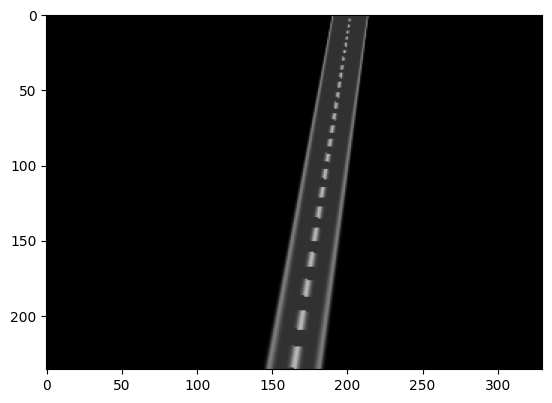

In [385]:
plt.imshow(viz_tensor[0])

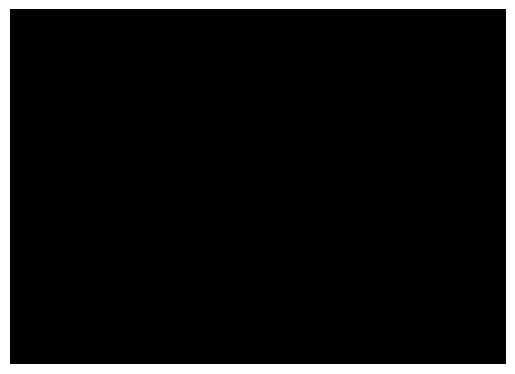

/tmp/ipykernel_27/3684256163.py:427: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  im = Image.fromarray((arr_rgba * 255).astype(np.uint8), mode="RGBA")


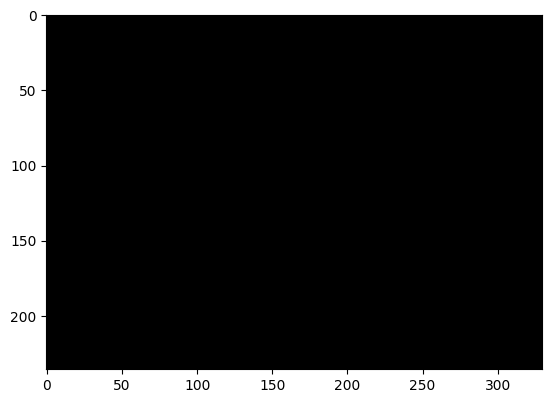

In [404]:
import numpy as np
from skimage.color import label2rgb
from PIL import Image


import numpy as np
from scipy.ndimage import label
from skimage.color import label2rgb
from skimage.morphology import erosion, square

import numpy as np
from scipy.ndimage import label
from skimage.color import label2rgb
from skimage.morphology import erosion
from skimage.morphology import binary_erosion  # boolean morphology

# single_class_bev.py
import os, cv2, numpy as np
from dataclasses import dataclass

# ---------- BEV core ----------
@dataclass
class BEVGrid:
    meters_per_pixel: float = 0.10
    forward_range_m: tuple[float, float] = (0.5, 40.0)     # (y_min, y_max)
    lateral_range_m: tuple[float, float] = (-8.0, 8.0)     # (x_min, x_max)

    @property
    def size(self) -> tuple[int, int]:
        x_min, x_max = self.lateral_range_m
        y_min, y_max = self.forward_range_m
        W_out = int(np.round((x_max - x_min) / self.meters_per_pixel))
        H_out = int(np.round((y_max - y_min) / self.meters_per_pixel))
        return (W_out, H_out)

    def scaling_matrix(self) -> np.ndarray:
        x_min, _x_max = self.lateral_range_m
        _y_min, y_max = self.forward_range_m
        mpp = self.meters_per_pixel
        return np.array([[ mpp,  0.0, x_min],
                         [ 0.0, -mpp, y_max],
                         [ 0.0,  0.0, 1.0 ]], dtype=np.float64)

class BEVProjector:
    def __init__(self, K: np.ndarray | None = None):
        self.K = None if K is None else self._validate_K(K)
        self.roll = 0.0; self.pitch = 0.0; self.yaw = 0.0; self.height_m = 1.0
        self._H_pg = None

    def set_intrinsics(self, K: np.ndarray):
        self.K = self._validate_K(K); self._H_pg = None; return self

    def set_pose(self, height_m: float, roll: float=0.0, pitch: float=0.0, yaw: float=0.0):
        self.height_m=float(height_m); self.roll=float(roll); self.pitch=float(pitch); self.yaw=float(yaw); self._H_pg=None; return self

    @staticmethod
    def _validate_K(K: np.ndarray) -> np.ndarray:
        K = np.asarray(K, dtype=np.float64)
        if K.shape != (3,3) or not np.isfinite(K).all():
            raise ValueError("K must be 3x3 finite")
        return K

    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        R_align = np.array([[1,0,0],[0,0,-1],[0,1,0]], dtype=np.float64)
        cz,sz = np.cos(yaw),np.sin(yaw)
        cy,sy = np.cos(pitch),np.sin(pitch)
        cx,sx = np.cos(roll),np.sin(roll)
        Rz = np.array([[cz,-sz,0],[sz,cz,0],[0,0,1]], np.float64)
        Ry = np.array([[cy,0,sy],[0,1,0],[-sy,0,cy]], np.float64)
        Rx = np.array([[1,0,0],[0,cx,-sx],[0,sx,cx]], np.float64)
        return R_align @ (Rx @ Ry @ Rz)

    def _ground_to_image_homography(self) -> np.ndarray:
        if self._H_pg is not None: return self._H_pg
        R_wc = self._rot_from_rpy(self.roll, self.pitch, self.yaw)
        t_wc = np.array([[0.0],[0.0],[self.height_m]], dtype=np.float64)
        r1, r2 = R_wc[:,0:1], R_wc[:,1:2]
        t = R_wc @ (-t_wc)
        self._H_pg = self.K @ np.hstack([r1, r2, t])
        return self._H_pg

def _build_intrinsics(W, H, K0=None, K0_size=None, fx=1100.0, fy=None):
    if K0 is not None and K0_size is not None:
        W0,H0 = K0_size; sx,sy = W/float(W0), H/float(H0)
        return np.array([[K0[0,0]*sx, 0, K0[0,2]*sx],
                         [0, K0[1,1]*sy, K0[1,2]*sy],
                         [0, 0, 1]], dtype=np.float64)
    if fy is None: fy = fx
    cx,cy = W/2.0, H/2.0
    return np.array([[fx,0,cx],[0,fy,cy],[0,0,1]], dtype=np.float64)

# ---------- Robust single-class mask creation ----------
def load_labels_to_mask_video(path: str, class_ids: tuple, *, background_ids=(0,), num_classes=20) -> np.ndarray:
    """
    Accepts labels either (T,H,W) of raw ids or (T,H,W,K) one-hot.
    Returns (T,H,W) binary in {0,1} for the chosen class_id (1..K).
    Ignores background and stray labels safely.
    """
    assert os.path.exists(path), f"not found: {path}"
    arr = np.load(path)
    
    if isinstance(class_ids, int):
        class_ids = (class_ids,)  # Ensure it's iterable

    if arr.ndim == 3:
        # raw ids
        T, H, W = arr.shape
        mask = np.isin(arr, class_ids).astype(np.uint8)
        for b in background_ids:
            mask[arr == b] = 0
        return mask

    elif arr.ndim == 4:
        # one-hot
        T, H, W, K = arr.shape
        for cid in class_ids:
            if not (1 <= cid <= K):
                raise ValueError(f"class_id {cid} not in 1..{K}")
        selected = [arr[..., cid-1] > 0 for cid in class_ids]
        mask = np.logical_or.reduce(selected).astype(np.uint8)
        return mask

    else:
        raise ValueError(f"Unexpected npy shape: {arr.shape}")
        
import numpy as np

def pick_bottom_middle_points(labeled, m, y_min=0, center_x=None):
    """
    labeled: (H,W) int array (0 = background, 1..K = components)
    m: keep components with size > m
    y_min: only return points with row >= y_min (i.e., 'below' that screen height)
    center_x: x-coordinate of 'screen middle' (defaults to W/2)

    Returns:
      coords: array of shape (P, 3) with [y, x, label] for kept components.
              P can be 0 if nothing passes filters.
    """
    labeled = np.asarray(labeled)
    assert labeled.ndim == 2, "Expected a single labeled image of shape (H, W)."
    H, W = labeled.shape
    if center_x is None:
        center_x = (W - 1) / 2.0
    bottom_y = H - 1

    # component sizes (ignore label 0)
    counts = np.bincount(labeled.ravel())
    if counts.size <= 1:
        return np.empty((0, 3), dtype=int)
    valid_labels = np.flatnonzero(counts > m)
    valid_labels = valid_labels[valid_labels != 0]
    if valid_labels.size == 0:
        return np.empty((0, 3), dtype=int)

    ys, xs = np.nonzero(labeled > 0)
    labs = labeled[ys, xs]

    # mask to only candidates from valid labels
    mask = np.isin(labs, valid_labels)
    ys, xs, labs = ys[mask], xs[mask], labs[mask]

    # distances to bottom-middle (Euclidean, squared is fine)
    d2 = (ys - bottom_y)**2 + (xs - center_x)**2

    # for each label, pick index of min distance
    # we’ll map labels -> best index using argmin per label
    best_idx = {}
    # iterate over all pixels once
    for i, L in enumerate(labs):
        if (L not in best_idx) or (d2[i] < d2[best_idx[L]]):
            best_idx[L] = i

    # collect chosen points
    chosen = []
    for L, i in best_idx.items():
        y, x = int(ys[i]), int(xs[i])
        if y >= y_min:  # only keep points below the cutoff line
            chosen.append((y, x, int(L)))

    if not chosen:
        return np.empty((0, 3), dtype=int)

    # sort by y descending (closest to bottom first), then by |x-center|
    chosen.sort(key=lambda t: (-(t[0]), abs(t[1] - center_x)))
    return np.asarray(chosen, dtype=int)


def pick_bottom_middle_points_batch(labeled_stack, m, y_min=0, center_x=None, batch_axis=0):
    """
    labeled_stack: (N,H,W) or (H,W,N) labeled maps
    Returns: list of length N, each item is an array (Pi, 3) with [y,x,label]
    """
    arr = np.moveaxis(labeled_stack, batch_axis, 0)  # -> (N,H,W)
    out = []
    for lbl in arr:
        out.append(pick_bottom_middle_points(lbl, m=m, y_min=y_min, center_x=center_x))
    return out


# Single image:
# pts -> array [[y, x, label], ...]

# Batch (N,H,W):
# pts_list[i] -> points for frame i





# ---------- Project (T,H,W) binary -> (T,Hb,Wb) binary ----------
def bev_project_binary_video(
    mask_video: np.ndarray,   # (T,H,W) in {0,1}
    *,
    height_m=1.4, pitch_deg_down=6.0, roll_deg=0.0, yaw_deg=0.0,
    fx=1100.0, fy=None, K0=None, K0_size=None,
    meters_per_pixel=0.10, forward_range=(0.5,40.0), lateral_range=(-8.0,8.0),
    binarize_threshold=127
):
    assert mask_video.ndim == 3
    T,H,W = mask_video.shape
    Kcam = _build_intrinsics(W,H,K0,K0_size,fx,fy)
    roll = np.deg2rad(roll_deg); pitch = -np.deg2rad(pitch_deg_down); yaw = np.deg2rad(yaw_deg)

    proj = BEVProjector().set_intrinsics(Kcam).set_pose(height_m, roll, pitch, yaw)
    grid = BEVGrid(meters_per_pixel=meters_per_pixel, forward_range_m=forward_range, lateral_range_m=lateral_range)

    H_pg = proj._ground_to_image_homography()
    S = grid.scaling_matrix()
    M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
    Wb,Hb = grid.size
    bev = np.zeros((T, Hb, Wb), dtype=np.uint8)

    for t in range(T):
        src = (mask_video[t].astype(np.uint8) * 255)
        dst = cv2.warpPerspective(src, M, (Wb,Hb), flags=cv2.INTER_NEAREST, borderValue=0)
        bev[t] = (dst > binarize_threshold).astype(np.uint8)
    return bev, proj, grid

# ---------- Fixed-canvas rotate+shift combine for two cams ----------
def rotate_shift_canvas_size(H, W, angle_deg, hor_shift_px):
    center = (W/2.0, H/2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)
    M1[0,2] -= hor_shift_px; M2[0,2] += hor_shift_px

    def corners(M):
        cs = np.array([[0,0],[W,0],[W,H],[0,H]], np.float32)
        ones = np.ones((4,1), np.float32)
        return (M @ np.hstack([cs,ones]).T).T

    allc = np.vstack([corners(M1), corners(M2)])
    min_xy = np.floor(allc.min(axis=0)).astype(int)
    max_xy = np.ceil(allc.max(axis=0)).astype(int)
    out_W = int(max_xy[0]-min_xy[0]); out_H = int(max_xy[1]-min_xy[1])
    return out_H, out_W, -int(min_xy[0]), -int(min_xy[1])

def combine_two_bev_single(bev_left: np.ndarray, bev_right: np.ndarray,
                           *, angle_deg: float, hor_shift_px: int) -> np.ndarray:
    """
    bev_left/right: (T,Hb,Wb) in {0,1}. Returns (T, Ho, Wo) in {0,1}.
    """
    assert bev_left.shape == bev_right.shape
    T,H,W = bev_left.shape
    out_H,out_W,sx,sy = rotate_shift_canvas_size(H,W,angle_deg,hor_shift_px)
    out = np.zeros((T,out_H,out_W), dtype=np.uint8)

    center = (W/2.0, H/2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)
    M1[0,2] += sx - hor_shift_px; M1[1,2] += sy
    M2[0,2] += sx + hor_shift_px; M2[1,2] += sy

    for t in range(T):
        L = (bev_left[t]*255).astype(np.uint8)
        R = (bev_right[t]*255).astype(np.uint8)
        w1 = cv2.warpAffine(L, M1, (out_W,out_H), flags=cv2.INTER_NEAREST, borderValue=0)
        w2 = cv2.warpAffine(R, M2, (out_W,out_H), flags=cv2.INTER_NEAREST, borderValue=0)
        out[t] = (cv2.add(w1,w2) > 127).astype(np.uint8)
    return out

def dilate_erode_blur_slice(
    image: np.ndarray, 
    kernel_size: int = 5,     
    blur_ksize: int = 7,
    blur_sigma: float = 1.0
    ) -> np.ndarray:
    """
    Performs dilation followed by erosion (closing) on the slice tensor_hwn[:, :, 50].

    Parameters:
        tensor_hwn (np.ndarray): Input tensor of shape (H, W, N)
        kernel_size (int): Size of the square kernel (default: 5)

    Returns:
        np.ndarray: Closed (dilated + eroded) version of slice [:, :, 50]
    """

    img = image.astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

    
    closed = cv2.erode(img, kernel)
    dilated = cv2.dilate(closed, kernel)

    
    blurred = cv2.GaussianBlur(dilated, (blur_ksize, blur_ksize), blur_sigma)

    

    return blurred

def erode_dilate_any(
    img,
    kernel_size_erode=(3, 3),
    kernel_size_dilate=(3, 3),
    iterations_erode=4,
    iterations_dilate=5,
):
    """
    Apply erode->dilate to a single image or a video stack.

    Accepts:
      - (H, W)                single-channel image/mask
      - (H, W, C)             color image
      - (T, H, W)             video of masks
      - (T, H, W, C)          video of color frames
    Returns array with the SAME shape as input, dtype uint8.
    """
    if any(s <= 0 for s in np.shape(img)):
        raise ValueError(f"Empty input with shape {np.shape(img)}")

    # Kernels (fix: use the correct tuple for each)
    k_erode  = cv2.getStructuringElement(cv2.MORPH_RECT,  tuple(kernel_size_erode))
    k_dilate = cv2.getStructuringElement(cv2.MORPH_RECT,  tuple(kernel_size_dilate))

    def _to_u8(a):
        if a.dtype == np.uint8:
            return a
        # Treat nonzero as foreground
        return (a > 0).astype(np.uint8) * 255

    def _morph2d(frame2d_or_3ch):
        f = _to_u8(frame2d_or_3ch)
        f = cv2.erode(f,  k_erode,  iterations=iterations_erode)
        f = cv2.dilate(f, k_dilate, iterations=iterations_dilate)
        return f

    arr = np.asarray(img)

    # Single image cases
    if arr.ndim == 2:                      # (H, W)
        return _morph2d(arr)
    if arr.ndim == 3 and arr.shape[-1] in (1, 3, 4):  # (H, W, C)
        return _morph2d(arr)

    # Video cases
    if arr.ndim == 3:                      # (T, H, W)
        out = np.empty_like(_to_u8(arr))
        for t in range(arr.shape[0]):
            out[t] = _morph2d(arr[t])
        return out

    if arr.ndim == 4 and arr.shape[-1] in (1, 3, 4):  # (T, H, W, C)
        out = np.empty_like(_to_u8(arr))
        for t in range(arr.shape[0]):
            out[t] = _morph2d(arr[t])
        return out

    raise ValueError(f"Unsupported input shape {arr.shape} for morphology.")


def color_segments_skimage_batch(arr, connectivity=8, horizontal_erosion_size=1, batch_axis=0):
    """
    arr: binary array with a batch axis (N,H,W) or (H,W,N)
    connectivity: 4 or 8
    horizontal_erosion_size: half-width of horizontal kernel (1 -> width=3)
    batch_axis: which axis is the batch (0 for (N,H,W), 2 for (H,W,N))
    returns: labeled_stack (N,H,W), rgb_stack (N,H,W,3)
    """
    # Move batch axis to axis 0 -> (N, H, W)
    arr = np.moveaxis(arr, batch_axis, 0)
    N, H, W = arr.shape

    # Horizontal structuring element: (1, kernel_width)
    selem = None
    if horizontal_erosion_size > 0:
        kernel_width = 2 * horizontal_erosion_size + 1
        selem = np.ones((1, kernel_width), dtype=bool)

    # Connectivity structure for labeling
    structure = np.ones((3,3), int) if connectivity == 8 else np.array([[0,1,0],[1,1,1],[0,1,0]], int)

    labeled_list = []
    rgb_list = []
    for i in range(N):
        binary = arr[i].astype(bool)

        if selem is not None:
            # Erode horizontally only (no vertical erosion)
            binary = binary_erosion(binary, footprint=selem)

        labeled, _ = label(binary, structure=structure)
        rgb = (255 * label2rgb(labeled, bg_label=0, bg_color=(0,0,0))).astype(np.uint8)

        labeled_list.append(labeled)
        rgb_list.append(rgb)

    labeled_stack = np.stack(labeled_list)       # (N,H,W)
    rgb_stack = np.stack(rgb_list)               # (N,H,W,3)

    # Move batch axis back to original place for both outputs
    labeled_stack = np.moveaxis(labeled_stack, 0, batch_axis)
    rgb_stack     = np.moveaxis(rgb_stack,     0, batch_axis)

    return labeled_stack, rgb_stack
    



# --- simple RGBA helpers ---
def load_rgba(path):
    im = Image.open(path).convert("RGBA")
    return np.asarray(im).astype(np.float32) / 255.0

def resize_rgba(arr_rgba, new_w=None, new_h=None):
    im = Image.fromarray((arr_rgba * 255).astype(np.uint8), mode="RGBA")
    if new_h and not new_w:
        new_w = int(round(im.width * (new_h / im.height)))
    elif new_w and not new_h:
        new_h = int(round(im.height * (new_w / im.width)))
    elif not (new_w and new_h):
        raise ValueError("Provide new_w or new_h (or both).")
    im = im.resize((new_w, new_h), Image.LANCZOS)
    return np.asarray(im).astype(np.float32) / 255.0

def alpha_over(base_u8, sprite_rgba, top, left):
    base = np.asarray(base_u8)
    H, W = base.shape[:2]
    sh, sw = sprite_rgba.shape[:2]

    y0, x0 = max(0, top), max(0, left)
    y1, x1 = min(H, top + sh), min(W, left + sw)
    if y0 >= y1 or x0 >= x1:
        return base

    sy0, sx0 = y0 - top, x0 - left
    sy1, sx1 = sy0 + (y1 - y0), sx0 + (x1 - x0)

    spr = sprite_rgba[sy0:sy1, sx0:sx1, :]         # (h,w,4) float32 [0,1]
    a   = spr[..., 3:4]
    rgb = spr[..., :3]

    # ensure base is RGB
    if base.ndim == 2:
        base = np.stack([base]*3, axis=-1)
    region = base[y0:y1, x0:x1, :].astype(np.float32) / 255.0
    out = rgb * a + region * (1.0 - a)

    base_out = base.copy().astype(np.float32)
    base_out[y0:y1, x0:x1, :] = out * 255.0
    return np.clip(base_out, 0, 255).astype(np.uint8)

def draw_icons_on_image(img_rgb_u8, pts, icon_path, width_px=48, height_px=None):
    """Draw icon at each (y,x) in pts on an RGB/gray image.

    If a point is on the LEFT half of the image, treat (y,x) as the icon's
    bottom-right corner; if it's on the RIGHT half, treat (y,x) as the
    bottom-left corner.
    """
    sprite0 = load_rgba(icon_path)
    sprite  = resize_rgba(sprite0, new_w=width_px) if height_px is None else resize_rgba(sprite0, new_w=width_px, new_h=height_px)

    # Accept pts as (y,x) or (y,x,label)
    pts = np.asarray(pts)
    if pts.ndim > 1 and pts.shape[-1] >= 2:
        pts = pts[:, :2]

    out = img_rgb_u8.copy()
    H, W = out.shape[:2]

    for (y, x) in pts:
        sh, sw = sprite.shape[:2]
        # Bottom aligns to y in both cases
        top = int(round(y - sh))
        left = int(x - (sw/2))
        out = alpha_over(out, sprite, top, left)

    return out


    

CLASS_ID = (18, 12)

cam1 = "/workspace/test_results/cam1_1754410796.npy"
cam2 = "/workspace/test_results/cam2_1754410796.npy"

# Build single-class masks then BEV per cam
mask1 = erode_dilate_any(load_labels_to_mask_video(cam1, CLASS_ID, background_ids=()), iterations_erode=8, iterations_dilate=10)
mask2 = erode_dilate_any(load_labels_to_mask_video(cam2, CLASS_ID, background_ids=()), iterations_erode=8, iterations_dilate=10)

bev1, proj1, grid1 = bev_project_binary_video(
    mask1, pitch_deg_down=0.0, height_m=1.0, fx=300, fy=int(530/380*200),
    meters_per_pixel=0.20, forward_range=(0.5,30.0), lateral_range=(-20.0,20.0)
)
bev2, proj2, grid2 = bev_project_binary_video(
    mask2, pitch_deg_down=0.0, height_m=1.0, fx=380.0, fy=530,
    meters_per_pixel=0.20, forward_range=(0.5,30.0), lateral_range=(-20.0,20.0)
)

# Combine cams in a fixed canvas
combined = combine_two_bev_single(
    bev_left=bev2, bev_right=bev1,  # follow your previous convention
    angle_deg=-35, hor_shift_px=-40
)
denoised = erode_dilate_any(combined, kernel_size_dilate=(3, 3), kernel_size_erode=(3,3), iterations_erode=0, iterations_dilate=5)


# quick sanity check image
import matplotlib.pyplot as plt
plt.imshow(denoised[0], cmap="gray"); plt.axis("off"); plt.show()


    

labeled, rgb = color_segments_skimage_batch(denoised, connectivity=8, horizontal_erosion_size=0, batch_axis=0)
plt.imshow(rgb[0])




ICON_PATH = "/workspace/CV/human_icon.png"   # set to your icon path
dot_images = []

for i in range(labeled.shape[0]):
    labeled_single = labeled[i]

    pts = pick_bottom_middle_points(
        labeled_single,
        m=0,
        y_min=int(0 * labeled_single.shape[0])
    )

    # Colorize the labeled map as background (like your dot viz)
    base_rgb = (label2rgb(labeled_single, bg_label=0, bg_color=(0,0,0)) * 255).astype(np.uint8)

    # Draw icons instead of dots
    base_rgb[:] = 0
    icon_img = draw_icons_on_image(
        base_rgb,
        pts,
        icon_path=ICON_PATH,
        width_px=20   # tweak as you like
    )

    dot_images.append(icon_img)

# Tensor (N, H, W, 3)
icon_tensor = np.stack(dot_images, axis=0)


In [266]:
icon_tensor.sum()

20298066

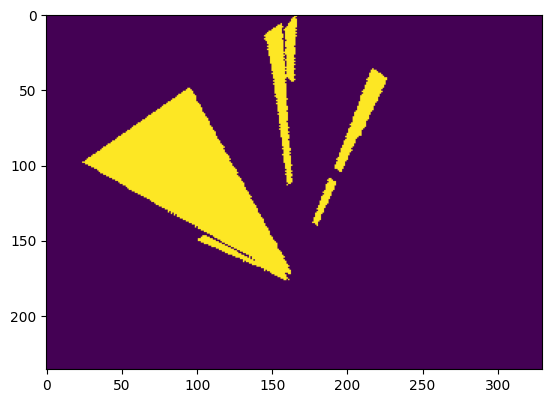

In [316]:
plt.imshow(combined[130])

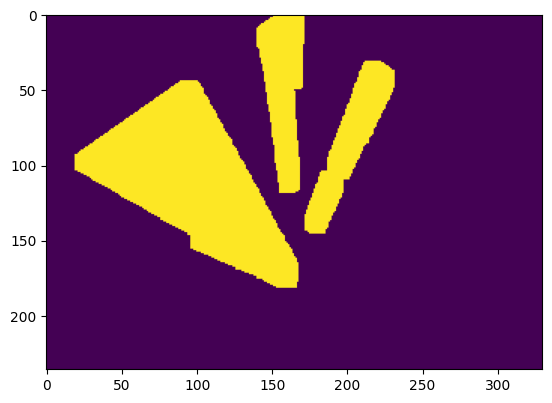

In [338]:
plt.imshow(denoised[130])

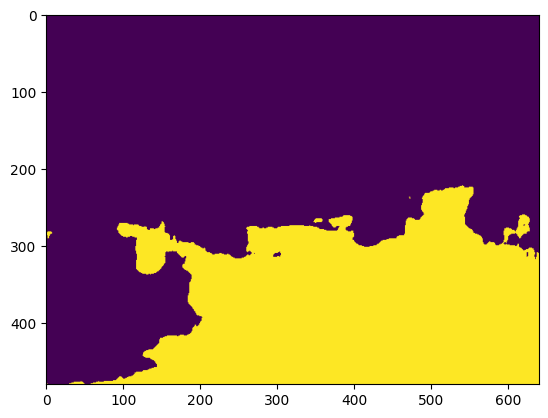

In [375]:
plt.imshow(np.isin(np.load(cam2)[125, :, :], (0, 1)))

In [406]:
import cv2

# Load video file
import cv2
import numpy as np

def load_video_to_numpy(video_path, resize_to=None, max_frames=None):
    """
    Load a video into a NumPy array.
    
    Parameters:
        video_path (str): Path to video file.
        resize_to (tuple): Optional (width, height) to resize each frame.
        max_frames (int): Optional maximum number of frames to load.
    
    Returns:
        np.ndarray: Array of shape (N, H, W, C), dtype=np.uint8
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {video_path}")

    frames = []
    count = 0

    while True:
        ret, frame = cap.read()
        if not ret or (max_frames is not None and count >= max_frames):
            break
        if resize_to is not None:
            frame = cv2.resize(frame, resize_to)
        frames.append(frame)
        count += 1

    cap.release()

    return np.stack(frames, axis=0)  # Shape: (N, H, W, C)
video_path = "/workspace/test_videos/cam2_1754410796.mp4"

# Example usage:
video_np2 = load_video_to_numpy(video_path, max_frames=300)
print("Video shape:", video_np.shape)  # Example: (300, 224, 224, 3)


Video shape: (300, 480, 640, 3)


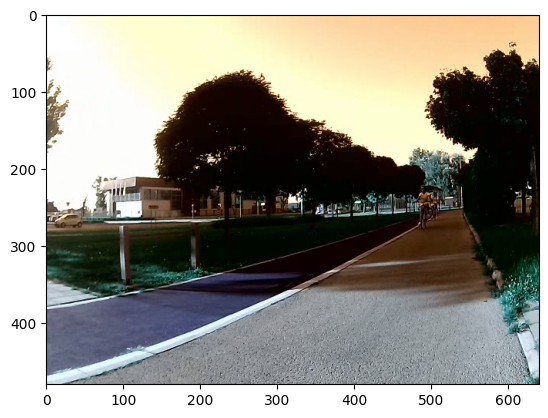

In [436]:
n = 160

plt.imshow(video_np1[n])

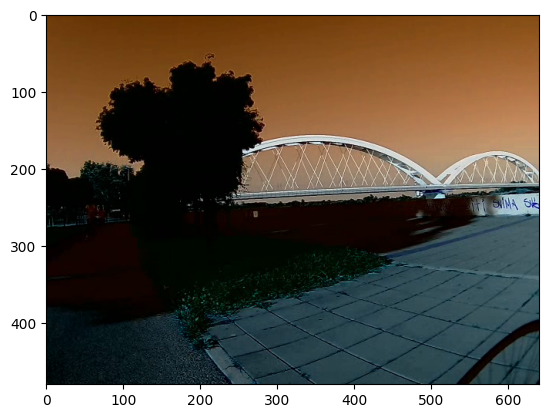

In [437]:
plt.imshow(video_np2[n])

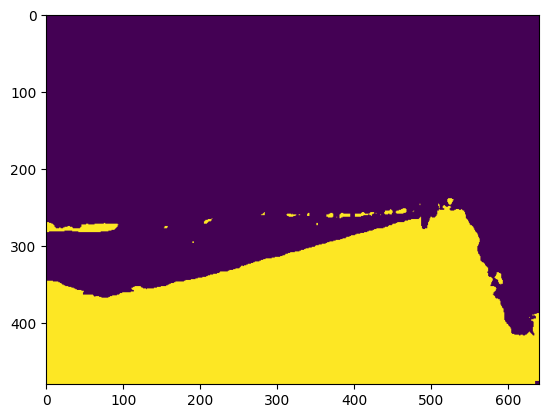

In [438]:
plt.imshow(np.isin(np.load(cam1)[n, :, :], (0, 1)))

In [439]:
icon_tensor.sum()

13505085

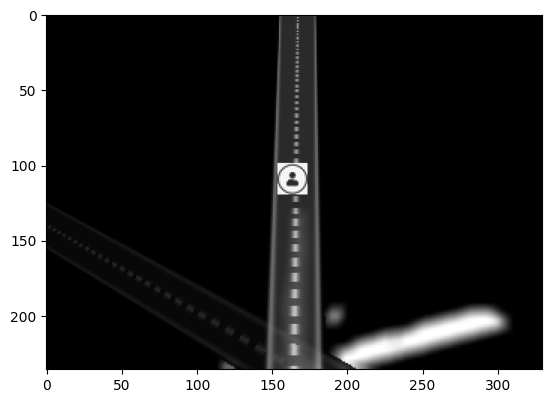

In [440]:
bajsplusput = np.transpose(np.maximum(combined_tensor, icon_tensor), (1, 2, 3, 0))
plt.imshow(bajsplusput[:, :, :, n])

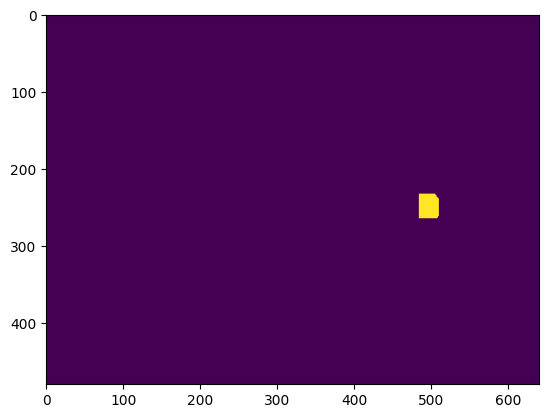

In [441]:
plt.imshow(mask1[n])

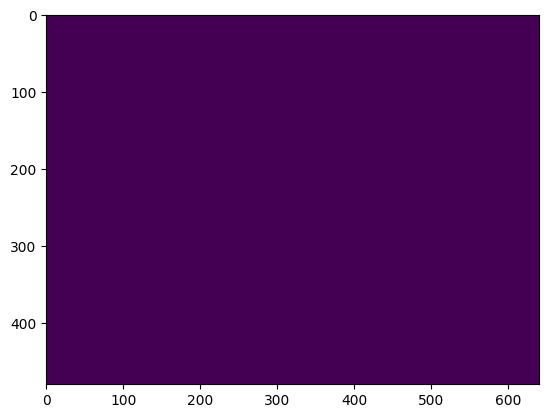

In [427]:
plt.imshow(mask2[n])

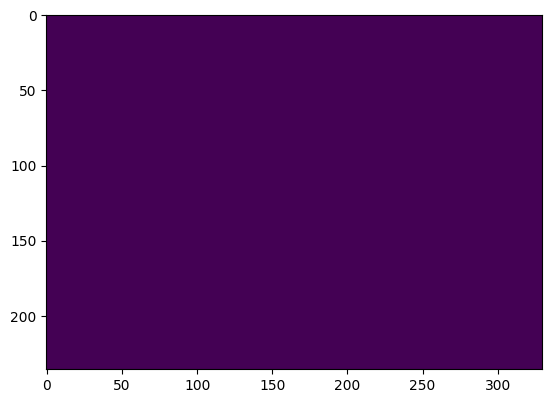

In [420]:
plt.imshow(denoised[n])

In [214]:
bajsplusput.shape


(236, 330, 3, 300)

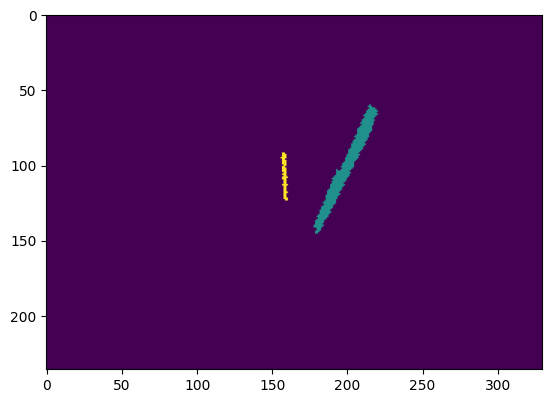

In [273]:
plt.imshow(labeled[n])

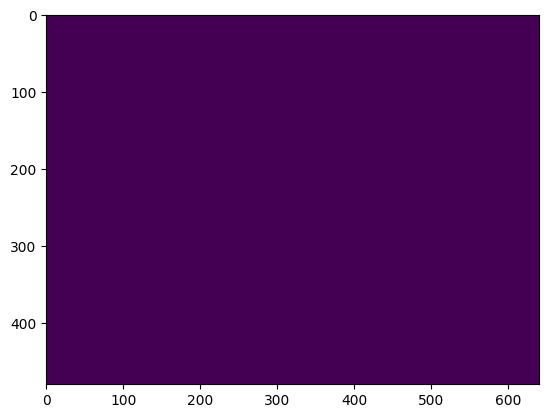

In [180]:
plt.imshow(mask1[n])

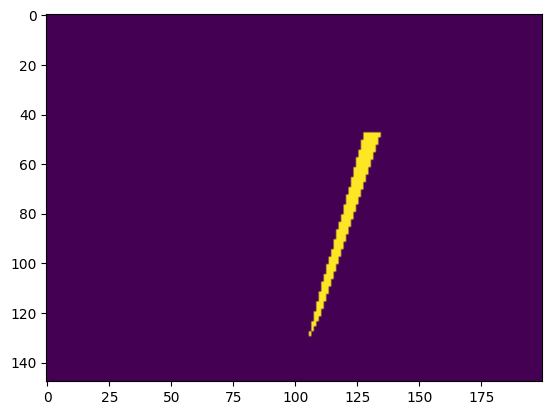

In [158]:
plt.imshow(bev1[n])

In [15]:
icon_tensor.sum()

3192111

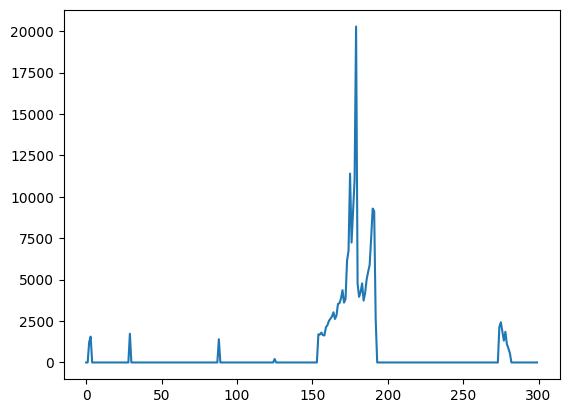

In [429]:
plt.plot(labeled.sum(axis = (1, 2)))

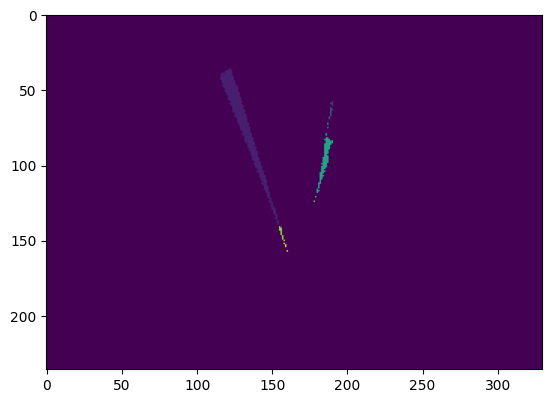

In [236]:
plt.imshow(labeled[125])

In [442]:

bajsplusput = np.transpose(np.maximum(combined_tensor, icon_tensor), (1, 2, 3, 0))

t2v(bajsplusput, fps = 15, out_path="CV/put+bajs.mp4")

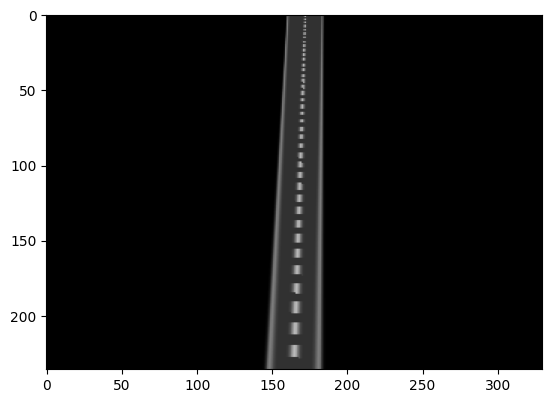

In [230]:
plt.imshow(np.maximum(viz_tensor, icon_tensor)[120])

In [47]:
np.maximum(viz_tensor)

TypeError: maximum() takes from 2 to 3 positional arguments but 1 were given